In [629]:
import Symbolics as Sym
using Nemo
using Statistics
using Distributions
using Combinatorics
using Random
using DataFrames
using Plots
using Latexify

import probability: prob, event_occurency, datas, ranks, face_cards, numbers

# Believe It or Not—Bayesian Probability

## Lecture 11

[T]his basic view of probability is called the frequentist probability,
because it’s talking about the frequency with which a repeated event
happens. But there’s another sense in which we often think in terms of
probability that measures really a quite different kind of phenomenon,
and so we sometimes wish to use probability to express in some sort of a
quantitative way the degree to which we believe something.

In [630]:
Sym.@variables p a b A B T NT n Ω; #use sets for events and prob space omega

In [631]:
P(x) = x

P (generic function with 1 method)

### Hypothesis & probability

When probability is used to express quantitatively a degree of belief, it must
be clear what all the possibilities are. Among the various potential states
of the world, we express the relative probabilities of those different states
being the correct one. And we assign to each such possible state of the world
a probability that that one is the correct one The sum of the probabilities
is 100%.

In [632]:
Ω_A =  Set(A)
Ω_B =  Set(B)
P(A ∪ B)

2-element Vector{Symbolics.Num}:
 A
 B

In [633]:
P(Ω_A ∪ Ω_B)

Set{Symbolics.Num} with 2 elements:
  A
  B

In [634]:
A ∩ B, Ω_A ⊆ Ω_B

(Symbolics.Num[], false)

In [635]:
A in B

A == B

To ground our discussion, let’s take an example of sh in a stream. We’re
interested in what fraction of sh in the stream are trout, from the possibilities
of 5%, 15%, 25%, …, 95%. Before any data are collected, we assume
that we have no bias; we establish the 10 possibilities and give each the
same probability

In [636]:
fish_prob_df = DataFrame(hypothesis_percentage = [5:10:95;], probability_hyp = repeat([0.10], 10))

Row,hypothesis_percentage,probability_hyp
,Int64,Float64
1,5,0.1
2,15,0.1
3,25,0.1
4,35,0.1
5,45,0.1
6,55,0.1
7,65,0.1
8,75,0.1
9,85,0.1


Suppose we catch three sh—trout/trout/non-trout. We would naturally
believe that it is more likely that the percentage of trout is high. We can
update our probabilities for the various potential percentages of trout in a
stream by doing a thought experiment in which we imagine 10,000,000
shermen—1,000,000 shing in each of 10 different universes (one for each
hypothesis). We can calculate how many of those fishermen would catch a
trout/trout/non-trout combination in their respective streams. The following
table shows our calculations:

In [637]:
Ω = [:T, :NT]

2-element Vector{Symbol}:
 :T
 :NT

In [638]:
fisher_mans = 1:1_000_000
fishers = 1:10
universes = 1:10;

In [639]:
E_speriment(fishers = fishers) = map(c -> rand(Ω, 3), fishers)

E_speriment (generic function with 2 methods)

In [640]:

E_fisherman(fisher_mans = fisher_mans) = map(f ->  count(e -> e ==  [:T, :T, :NT], E_speriment()), fisher_mans);

In [641]:
result = map( c -> sum(E_fisherman(1:c:rand(fisher_mans))), universes)

10-element Vector{Int64}:
 524671
 320227
  83518
 281235
 229251
  82369
  29807
   4851
  59392
  36965

In [642]:
total = sum(map(s -> sum(s), result))

1652286

In [643]:
fish_prob_df[!, :fisher_mans_sequeces_count] = result;
fish_prob_df[!, :posterior_percentages] = collect(Iterators.flatmap(sc -> sc/total, result));
fish_prob_df

Row,hypothesis_percentage,probability_hyp,fisher_mans_sequeces_count,posterior_percentages
,Int64,Float64,Int64,Float64
1,5,0.1,524671,0.317542
2,15,0.1,320227,0.193808
3,25,0.1,83518,0.0505469
4,35,0.1,281235,0.17021
5,45,0.1,229251,0.138748
6,55,0.1,82369,0.0498515
7,65,0.1,29807,0.0180399
8,75,0.1,4851,0.00293593
9,85,0.1,59392,0.0359454


By applying Bayes’ theorem to make an update to our previous resulting
distribution, we get a new distribution that has most of the probability
concentrated in the choices

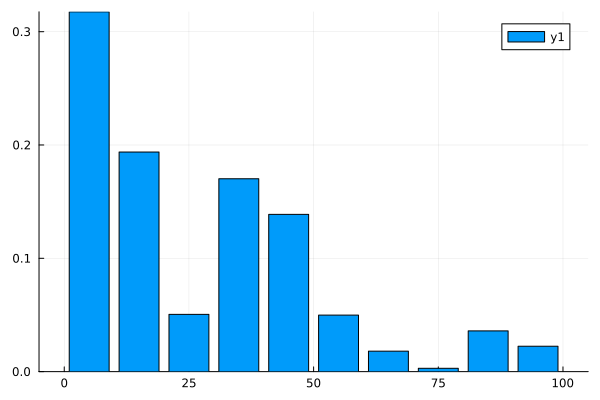

In [644]:
bar(fish_prob_df.hypothesis_percentage, fish_prob_df.posterior_percentages)

If we catch
another trout and another non-trout, we can perform the same type of
calculations using our new, updated distribution. Now we have evidence
that changes our sense of the possibility; we have, for example, many more
shermen in the

In [645]:
E_speriment(fishers = fishers) = map(c -> rand(Ω, 4), fishers)

E_speriment (generic function with 2 methods)

In [646]:

E_fisherman(fisher_mans = fisher_mans) = map(f ->  count(e -> e ==  [:T, :T, :NT, :NT], E_speriment()), fisher_mans);

In [647]:
result = map( c -> sum(E_fisherman(1:c:rand(fisher_mans))), universes)
total = sum(map(s -> sum(s), result))
fish_prob_df[!, :fisher_mans_sequeces_count] = result;
fish_prob_df[!, :posterior_percentages] = collect(Iterators.flatmap(sc -> sc/total, result));
fish_prob_df

Row,hypothesis_percentage,probability_hyp,fisher_mans_sequeces_count,posterior_percentages
,Int64,Float64,Int64,Float64
1,5,0.1,462055,0.426071
2,15,0.1,145425,0.134099
3,25,0.1,107696,0.0993088
4,35,0.1,139695,0.128816
5,45,0.1,79610,0.0734101
6,55,0.1,46553,0.0429275
7,65,0.1,7711,0.00711048
8,75,0.1,55614,0.0512829
9,85,0.1,24756,0.022828


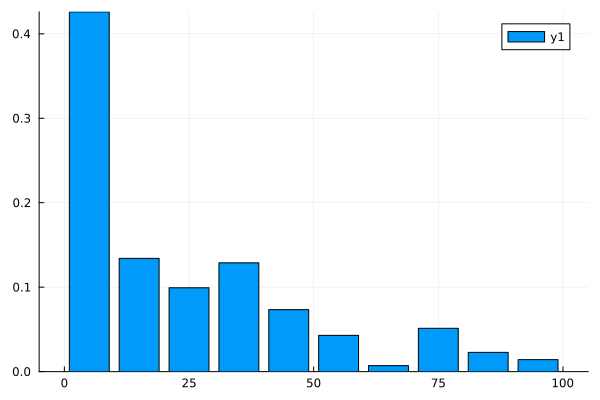

In [648]:
bar(fish_prob_df.hypothesis_percentage, fish_prob_df.posterior_percentages)

Thus, we have two views of probability. The frequentist probability is the
view in which probability is de ned in terms of long-run frequency or
proportion in outcomes of repeated experiments.

**Bayesian probability is the view in which probability is interpreted as a measure of degree of belief.**
In this view, the concept of probability distribution is applied to a feature of a
population to indicate one’s belief about possible values of that feature.

Let’s look at another example of updating our probability distribution in the
field of medicine. A doctor narrows a patient’s illness to three possibilities:
A, B, or C. After assessing the patient, the doctor assigns probabilities of
the patient having the diseases as follows: A: 50%, B: 40%, C: 10%. After
a more thorough exam, a symptom, S, is discovered, and the doctor knows
what the probability is of a patient with each of the diseases exhibiting
this symptom.

In [667]:
diseases_hypothesis_prob = Dict(:A => 50, :B => 40, :C => 10)
imagened = 10_000
total_patients = 2500

2500

Therefore, we update our initial probability distribution:

In [670]:
diagnosis_df = DataFrame(
    hypothesis_has_disease = collect(keys(diseases_hypothesis_prob)), 
    probability_hypothesis = collect(values(diseases_hypothesis_prob)), 
    number_imagined_patients = map(n ->   round(Int, n * (imagened / 100)), values(diseases_hypothesis_prob)), 
    probability_of_S = [10, 30, 80],
    number_of_patients_S = [diseases_hypothesis_prob[:A] * 10, 
    diseases_hypothesis_prob[:B] * 30, diseases_hypothesis_prob[:C] * 80])

Row,hypothesis_has_disease,probability_hypothesis,number_imagined_patients,probability_of_S,number_of_patients_S
,Symbol,Int64,Int64,Int64,Int64
1,A,50,5000,10,500
2,B,40,4000,30,1200
3,C,10,1000,80,800


In [678]:
diagnosis_df[!, :updated_hypothesis] = diagnosis_df.number_of_patients_S / total_patients
diagnosis_df

Row,hypothesis_has_disease,probability_hypothesis,number_imagined_patients,probability_of_S,number_of_patients_S,updated_hypothesis
,Symbol,Int64,Int64,Int64,Int64,Float64
1,A,50,5000,10,500,0.2
2,B,40,4000,30,1200,0.48
3,C,10,1000,80,800,0.32


**We see that B is now the most probable disease, replacing disease A.**